# Optional Lab: Model Representation

<figure>
 <img src="./images/C1_W1_L3_S1_Lecture_b.png"   style="width:600px;height:200px;">
</figure>

## Goals
In this lab you will:
- Learn to implement the model $f_{w,b}$ for linear regression with one variable

## Notation
Here is a summary of some of the notation you will encounter.  

|General <img width=70/> <br />  Notation  <img width=70/> | Description<img width=350/>| Python (if applicable) |
|: ------------|: ------------------------------------------------------------||
| $a$ | scalar, non bold                                                      ||
| $\mathbf{a}$ | vector, bold                                                      ||
| **Regression** |         |    |     |
|  $\mathbf{x}$ | Training Example feature values (in this lab - Size (1000 sqft))  | `x_train` |   
|  $\mathbf{y}$  | Training Example  targets (in this lab Price (1000s of dollars))  | `y_train` 
|  $x^{(i)}$, $y^{(i)}$ | $i_{th}$Training Example | `x_i`, `y_i`|
| m | Number of training examples | `m`|
|  $w$  |  parameter: weight                                 | `w`    |
|  $b$           |  parameter: bias                                           | `b`    |     
| $f_{w,b}(x^{(i)})$ | The result of the model evaluation at $x^{(i)}$ parameterized by $w,b$: $f_{w,b}(x^{(i)}) = wx^{(i)}+b$  | `f_wb` | 


## Tools
In this lab you will make use of: 
- NumPy, a popular library for scientific computing
- Matplotlib, a popular library for plotting data

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Alterando o estilo do gráfico para algo integrado no Matplotlib
plt.style.use('ggplot')  # Estilo mais visual e fácil de ler

# Configurações adicionais de estilo (opcional)
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['grid.color'] = '#cccccc'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

# Problem Statement
<img align="left" src="./images/C1_W1_L3_S1_trainingdata.png"    style=" width:380px; padding: 10px;  " /> 

As in the lecture, you will use the motivating example of housing price prediction.  
This lab will use a simple data set with only two data points - a house with 1000 square feet(sqft) sold for \\$300,000 and a house with 2000 square feet sold for \\$500,000. These two points will constitute our *data or training set*. In this lab, the units of size are 1000 sqft and the units of price are 1000s of dollars.

| Size (1000 sqft)     | Price (1000s of dollars) |
| -------------------| ------------------------ |
| 1.0               | 300                      |
| 2.0               | 500                      |

You would like to fit a linear regression model (shown above as the blue straight line) through these two points, so you can then predict price for other houses - say, a house with 1200 sqft.


Please run the following code cell to create your `x_train` and `y_train` variables. The data is stored in one-dimensional NumPy arrays.

Conjunto de dados de treinamento:
Casa 1: Tamanho = 1.0 mil sqft, Preço = $300000.00
Casa 2: Tamanho = 2.0 mil sqft, Preço = $500000.00
Casa 3: Tamanho = 3.0 mil sqft, Preço = $700000.00
Casa 4: Tamanho = 4.0 mil sqft, Preço = $900000.00


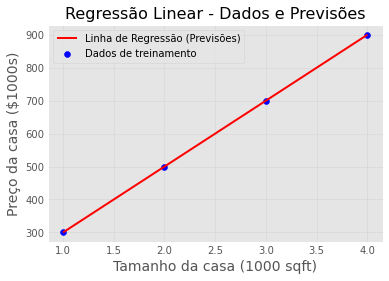

Erro Médio Absoluto (MAE): 0.00

Previsões para novas casas:
Casa de 1.5 mil sqft: Preço estimado = $400000.00
Casa de 2.5 mil sqft: Preço estimado = $600000.00
Casa de 3.5 mil sqft: Preço estimado = $800000.00


In [11]:
# x_train é a variável de entrada (tamanho da casa em 1000 sqft)
# y_train é a variável alvo (preço da casa em 1000s de dólares)

# Adicionando mais pontos de treinamento para enriquecer o conjunto de dados
x_train = np.array([1.0, 2.0, 3.0, 4.0])  # Tamanhos de casas em 1000 sqft
y_train = np.array([300.0, 500.0, 700.0, 900.0])  # Preços em $1000s

# Exibindo os dados para validação
print("Conjunto de dados de treinamento:")
for i in range(len(x_train)):
    print(f"Casa {i+1}: Tamanho = {x_train[i]} mil sqft, Preço = ${y_train[i]*1000:.2f}")

# Função de predição (y = wx + b)
def predict(x, w, b):
    return w * x + b

# Configurando parâmetros da linha de regressão
w = 200  # Peso
b = 100  # Viés

# Gerando previsões baseadas na linha de regressão
y_pred = predict(x_train, w, b)

# Plotando os pontos de treinamento e a linha de regressão
plt.scatter(x_train, y_train, color="blue", label="Dados de treinamento")
plt.plot(x_train, y_pred, color="red", label="Linha de Regressão (Previsões)")
plt.xlabel("Tamanho da casa (1000 sqft)")
plt.ylabel("Preço da casa ($1000s)")
plt.title("Regressão Linear - Dados e Previsões")
plt.legend()
plt.grid(True)
plt.show()

# Calculando o erro médio absoluto (MAE)
def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

mae = mean_absolute_error(y_train, y_pred)
print(f"Erro Médio Absoluto (MAE): {mae:.2f}")

# Prevendo preços para novos tamanhos de casas
x_test = np.array([1.5, 2.5, 3.5])  # Novos tamanhos de casas
y_test_pred = predict(x_test, w, b)

print("\nPrevisões para novas casas:")
for i, size in enumerate(x_test):
    print(f"Casa de {size} mil sqft: Preço estimado = ${y_test_pred[i] * 1000:.2f}")

>**Note**: The course will frequently utilize the python 'f-string' output formatting described [here](https://docs.python.org/3/tutorial/inputoutput.html) when printing. The content between the curly braces is evaluated when producing the output.

### Number of training examples `m`
You will use `m` to denote the number of training examples. Numpy arrays have a `.shape` parameter. `x_train.shape` returns a python tuple with an entry for each dimension. `x_train.shape[0]` is the length of the array and number of examples as shown below.

In [12]:
# Número de exemplos de treinamento usando .shape
print(f"x_train.shape: {x_train.shape}")
m = x_train.shape[0]  # Obtém o número de linhas no array
print(f"Número de exemplos de treinamento: {m}")

x_train.shape: (4,)
Número de exemplos de treinamento: 4


One can also use the Python `len()` function as shown below.

In [13]:
# Calculando o número de exemplos de treinamento usando len()
m = len(x_train)
print(f"O conjunto de treinamento contém {m} exemplos (usando len()).")

O conjunto de treinamento contém 4 exemplos (usando len()).


### Training example `x_i, y_i`

You will use (x$^{(i)}$, y$^{(i)}$) to denote the $i^{th}$ training example. Since Python is zero indexed, (x$^{(0)}$, y$^{(0)}$) is (1.0, 300.0) and (x$^{(1)}$, y$^{(1)}$) is (2.0, 500.0). 

To access a value in a Numpy array, one indexes the array with the desired offset. For example the syntax to access location zero of `x_train` is `x_train[0]`.
Run the next code block below to get the $i^{th}$ training example.

In [14]:
# Acessando um exemplo de treinamento específico
i = 0  # Altere o índice para visualizar outros exemplos (0, 1, etc.)
x_i = x_train[i]
y_i = y_train[i]

# Exibindo o exemplo selecionado
print(f"Exemplo {i + 1}: x({i}) = {x_i}, y({i}) = {y_i}")

# Opcional: Exibir todos os exemplos para validação
print("\nTodos os exemplos de treinamento:")
for idx in range(len(x_train)):
    print(f"Exemplo {idx + 1}: x({idx}) = {x_train[idx]}, y({idx}) = {y_train[idx]}")

Exemplo 1: x(0) = 1.0, y(0) = 300.0

Todos os exemplos de treinamento:
Exemplo 1: x(0) = 1.0, y(0) = 300.0
Exemplo 2: x(1) = 2.0, y(1) = 500.0
Exemplo 3: x(2) = 3.0, y(2) = 700.0
Exemplo 4: x(3) = 4.0, y(3) = 900.0


### Plotting the data

You can plot these two points using the `scatter()` function in the `matplotlib` library, as shown in the cell below. 
- The function arguments `marker` and `c` show the points as red crosses (the default is blue dots).

You can use other functions in the `matplotlib` library to set the title and labels to display

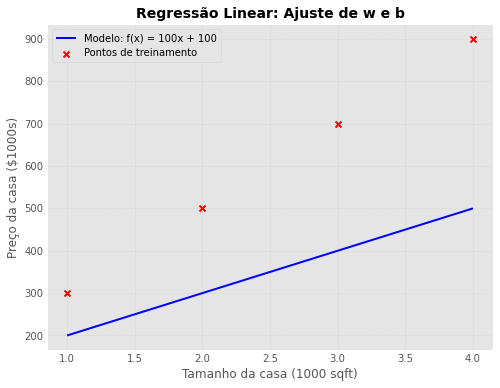

Valores calculados:
Tamanho da casa: 1.0k sqft -> Preço estimado: 200.00k
Tamanho da casa: 2.0k sqft -> Preço estimado: 300.00k
Tamanho da casa: 3.0k sqft -> Preço estimado: 400.00k
Tamanho da casa: 4.0k sqft -> Preço estimado: 500.00k


In [17]:
# Importando bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt

# Dados de treinamento
x_train = np.array([1.0, 2.0, 3.0, 4.0])  # Tamanhos das casas em 1000 sqft
y_train = np.array([300.0, 500.0, 700.0, 900.0])  # Preços em $1000s

# Função do modelo: f(x) = wx + b
def model(x, w, b):
    return w * x + b

# Valores iniciais de w e b
w = 100  # Peso (slope da linha)
b = 100  # Viés (intercepto da linha)

# Calculando as previsões para o conjunto de treinamento
y_pred = model(x_train, w, b)

# Plotando os pontos e a linha do modelo
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, marker='x', c='r', label='Pontos de treinamento')
plt.plot(x_train, y_pred, linestyle='-', color='blue', label=f'Modelo: f(x) = {w}x + {b}')
plt.title("Regressão Linear: Ajuste de w e b", fontsize=14, fontweight='bold')
plt.xlabel("Tamanho da casa (1000 sqft)", fontsize=12)
plt.ylabel("Preço da casa ($1000s)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.show()

# Exibindo os valores calculados
print("Valores calculados:")
for i in range(len(x_train)):
    print(f"Tamanho da casa: {x_train[i]}k sqft -> Preço estimado: {y_pred[i]:.2f}k")


## Model function

<img align="left" src="./images/C1_W1_L3_S1_model.png"     style=" width:380px; padding: 10px; " > As described in lecture, the model function for linear regression (which is a function that maps from `x` to `y`) is represented as 

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

The formula above is how you can represent straight lines - different values of $w$ and $b$ give you different straight lines on the plot. <br/> <br/> <br/> <br/> <br/> 

Let's try to get a better intuition for this through the code blocks below. Let's start with $w = 100$ and $b = 100$. 

**Note: You can come back to this cell to adjust the model's w and b parameters**

In [18]:
# Definindo os parâmetros do modelo
w = 100
b = 100

# Exibindo os valores de w e b
print(f"w: {w}")
print(f"b: {b}")

# Calculando manualmente f_wb para os dois primeiros pontos de dados
x_train = [1.0, 2.0]  # Tamanhos das casas em 1000 sqft
f_wb_0 = w * x_train[0] + b  # Para x^(0)
f_wb_1 = w * x_train[1] + b  # Para x^(1)

# Exibindo os resultados
print(f"f_wb para x^(0): {f_wb_0}")
print(f"f_wb para x^(1): {f_wb_1}")

w: 100
b: 100
f_wb para x^(0): 200.0
f_wb para x^(1): 300.0


Now, let's compute the value of $f_{w,b}(x^{(i)})$ for your two data points. You can explicitly write this out for each data point as - 

for $x^{(0)}$, `f_wb = w * x[0] + b`

for $x^{(1)}$, `f_wb = w * x[1] + b`

For a large number of data points, this can get unwieldy and repetitive. So instead, you can calculate the function output in a `for` loop as shown in the `compute_model_output` function below.
> **Note**: The argument description `(ndarray (m,))` describes a Numpy n-dimensional array of shape (m,). `(scalar)` describes an argument without dimensions, just a magnitude.  
> **Note**: `np.zero(n)` will return a one-dimensional numpy array with $n$ entries   


In [19]:
import numpy as np

# Função para calcular a previsão de um modelo linear
def compute_model_output(x, w, b):
    """
    Calcula a previsão de um modelo linear
    Args:
        x (ndarray (m,)): Dados, m exemplos
        w, b (escalar): Parâmetros do modelo
    Returns:
        f_wb (ndarray (m,)): Previsões do modelo
    """
    m = x.shape[0]  # Número de exemplos de treinamento
    f_wb = np.zeros(m)  # Inicializando f_wb com zeros
    
    for i in range(m):
        f_wb[i] = w * x[i] + b  # Calculando f_wb para cada exemplo
    
    return f_wb

# Testando a função
x_train = np.array([1.0, 2.0, 3.0, 4.0])  # Tamanhos das casas em 1000 sqft
w = 100
b = 100
f_wb = compute_model_output(x_train, w, b)

# Exibindo as previsões
print(f"Previsões do modelo: {f_wb}")

Previsões do modelo: [200. 300. 400. 500.]


Now let's call the `compute_model_output` function and plot the output..

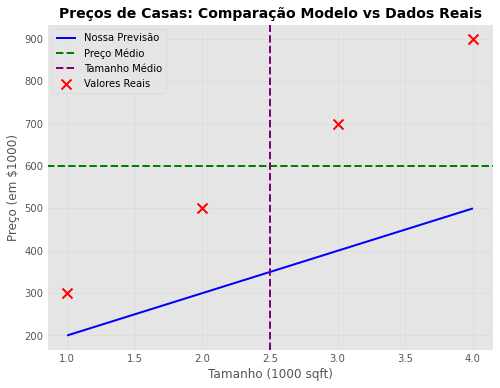

Erros para cada ponto de treinamento:
Caso 1: Erro = 100.00
Caso 2: Erro = 200.00
Caso 3: Erro = 300.00
Caso 4: Erro = 400.00


In [20]:
# Calcular previsões do modelo
tmp_f_wb = compute_model_output(x_train, w, b)

# Configurando o tamanho do gráfico
plt.figure(figsize=(8, 6))

# Plotando a previsão do modelo
plt.plot(x_train, tmp_f_wb, c='b', label='Nossa Previsão', linewidth=2)

# Plotando os pontos de dados reais
plt.scatter(x_train, y_train, marker='x', c='r', label='Valores Reais', s=100)

# Adicionando título e rótulos com formatação
plt.title("Preços de Casas: Comparação Modelo vs Dados Reais", fontsize=14, fontweight='bold')
plt.ylabel('Preço (em $1000)', fontsize=12)
plt.xlabel('Tamanho (1000 sqft)', fontsize=12)

# Adicionando uma linha para indicar o preço médio
plt.axhline(np.mean(y_train), color='green', linestyle='--', label='Preço Médio')

# Adicionando uma linha para indicar o tamanho médio
plt.axvline(np.mean(x_train), color='purple', linestyle='--', label='Tamanho Médio')

# Adicionando grade para melhorar a visualização
plt.grid(True, linestyle='--', alpha=0.7)

# Exibindo legenda com formatação
plt.legend(fontsize=10, loc='upper left')

# Exibindo o gráfico
plt.show()

# Calculando e exibindo erros para análise
errors = y_train - tmp_f_wb
print("Erros para cada ponto de treinamento:")
for i in range(len(errors)):
    print(f"Caso {i + 1}: Erro = {errors[i]:.2f}")

As you can see, setting $w = 100$ and $b = 100$ does *not* result in a line that fits our data. 

### Challenge
Try experimenting with different values of $w$ and $b$. What should the values be for a line that fits our data?

#### Tip:
You can use your mouse to click on the green "Hints" below to reveal some hints for choosing b and w.

<details>
<summary>
    <font size='3', color='darkgreen'><b>Hints</b></font>
</summary>
    <p>
    <ul>
        <li>Try $w = 200$ and $b = 100$ </li>
    </ul>
    </p>

### Prediction
Now that we have a model, we can use it to make our original prediction. Let's predict the price of a house with 1200 sqft. Since the units of $x$ are in 1000's of sqft, $x$ is 1.2.


In [21]:
# Parâmetros do modelo (w: inclinação, b: intercepto)
w = 200  # Inclinação da linha de regressão
b = 100  # Intercepto da linha de regressão

# Tamanho da casa em 1000 sqft (1200 sqft = 1.2 em unidades do modelo)
x_i = 1.2  

# Calculando o preço previsto para uma casa de 1200 sqft
predicted_price = w * x_i + b

# Exibindo o resultado formatado
print(f"Para uma casa de 1200 sqft, o preço estimado é: ${predicted_price:,.2f} mil dólares")

# Explicação adicional para apresentação
print("\nDetalhes do cálculo:")
print(f"Inclinação (w): {w}")
print(f"Intercepto (b): {b}")
print(f"Tamanho da casa (x): {x_i * 1000:.0f} sqft")
print(f"Preço estimado: ${predicted_price * 1000:,.2f}")

Para uma casa de 1200 sqft, o preço estimado é: $340.00 mil dólares

Detalhes do cálculo:
Inclinação (w): 200
Intercepto (b): 100
Tamanho da casa (x): 1200 sqft
Preço estimado: $340,000.00


# Congratulations!
In this lab you have learned:
 - Linear regression builds a model which establishes a relationship between features and targets
     - In the example above, the feature was house size and the target was house price
     - for simple linear regression, the model has two parameters $w$ and $b$ whose values are 'fit' using *training data*.
     - once a model's parameters have been determined, the model can be used to make predictions on novel data.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# Dados de treinamento
x_train = np.array([1.0, 2.0, 3.0, 4.0])  # Tamanhos das casas em 1000 sqft
y_train = np.array([300.0, 500.0, 700.0, 900.0])  # Preços em $1000s

# Função para calcular as previsões do modelo
def compute_model_output(x, w, b):
    return w * x + b

# Função interativa para visualização
def interactive_plot(w=200, b=100):
    # Calculando as previsões
    y_pred = compute_model_output(x_train, w, b)
    
    # Plotando os dados e a linha do modelo
    plt.figure(figsize=(8, 6))
    plt.scatter(x_train, y_train, color="red", label="Pontos de Treinamento", marker="x")
    plt.plot(x_train, y_pred, color="blue", label=f"Modelo: f(x) = {w}x + {b}")
    plt.title("Regressão Linear Interativa", fontsize=16, fontweight="bold")
    plt.xlabel("Tamanho da casa (1000 sqft)", fontsize=12)
    plt.ylabel("Preço da casa ($1000s)", fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=10)
    plt.show()

# Criando o widget interativo
interact(interactive_plot, w=(100, 300, 10), b=(50, 150, 10))

interactive(children=(IntSlider(value=200, description='w', max=300, min=100, step=10), IntSlider(value=100, d…

<function __main__.interactive_plot(w=200, b=100)>